In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import datetime as dt

# 1. Load dataset

In [2]:
df = pd.read_csv(r"D:\Data_Analystics\Retail\superstore.csv")

# 2. Derive unit price and profit margin

In [3]:
df['Profit_Margin'] = df['Profit'] / df['Sales']
df['Unit_Price'] = df['Sales'] / df['Quantity']

# 3. Select numerical variables for correlation

In [4]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']
corr_matrix = df[numeric_cols].corr(method='pearson')

# 4. Generate visualization

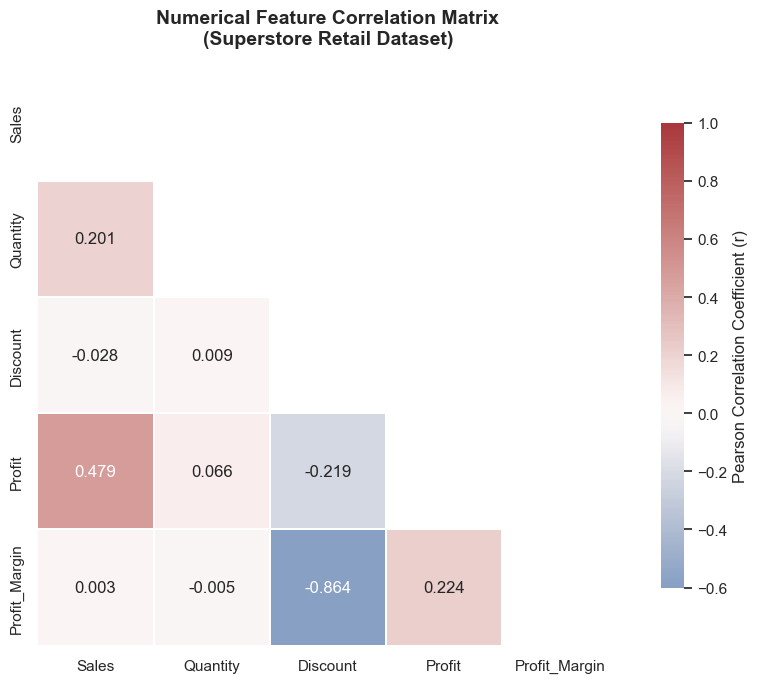

In [5]:
plt.figure(figsize=(9, 7))
sns.set_theme(style='white')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(20, 220, as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    mask=mask,
    cmap='vlag',
    vmin=-0.6,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=1.2,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Coefficient (r)'},
)

plt.title(
    'Numerical Feature Correlation Matrix\n(Superstore Retail Dataset)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# 5. Print correlation values to terminal

In [6]:
print('--- Pearson Correlation Matrix ---')
print(corr_matrix.round(4))

--- Pearson Correlation Matrix ---
                Sales  Quantity  Discount  Profit  Profit_Margin
Sales          1.0000    0.2008   -0.0282  0.4791         0.0034
Quantity       0.2008    1.0000    0.0086  0.0663        -0.0053
Discount      -0.0282    0.0086    1.0000 -0.2195        -0.8645
Profit         0.4791    0.0663   -0.2195  1.0000         0.2237
Profit_Margin  0.0034   -0.0053   -0.8645  0.2237         1.0000


# Q2: Profit Distribution & Outlier Detection by Sub-Category!

# 1. Sub-category distributional metrics

In [7]:
subcat_stats = (
    df.groupby('Sub-Category')['Profit']
    .agg(
        Order_Count='count',
        Total_Profit='sum',
        Mean_Profit='mean',
        Median_Profit='median',
        Std_Profit='std',
        Min_Profit='min',
        Max_Profit='max',
        Loss_Count=lambda x: (x < 0).sum(),
    )
    .reset_index()
)

subcat_stats['Loss_Rate_Pct'] = (
    subcat_stats['Loss_Count'] / subcat_stats['Order_Count']
) * 100

# 2. Detect extreme negative outliers per sub-category (IQR rule: Q1 - 1.5 * IQR)

In [8]:
def count_severe_negative_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    return (series < lower_bound).sum()


subcat_outliers = (
    df.groupby('Sub-Category')['Profit']
    .apply(count_severe_negative_outliers)
    .reset_index(name='Severe_Neg_Outliers')
)
subcat_stats = pd.merge(
    subcat_stats, subcat_outliers, on='Sub-Category'
).sort_values(by='Total_Profit', ascending=False)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18076\2320155177.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


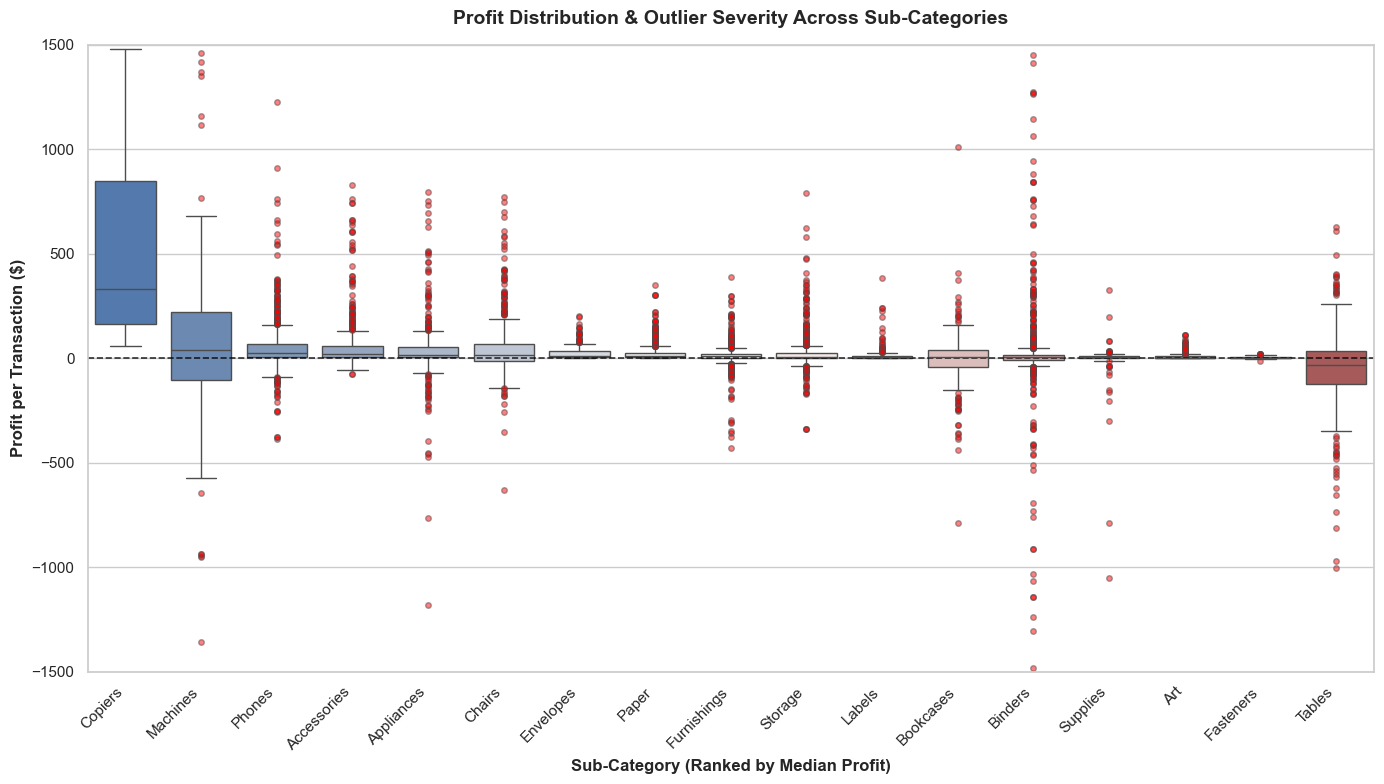

Sub-Category  Order_Count  Total_Profit  Mean_Profit  Median_Profit  Loss_Rate_Pct  Min_Profit  Severe_Neg_Outliers
     Copiers           68    55617.8249   817.909190      332.99420       0.000000     59.9980                    0
      Phones          889    44515.7306    50.073938       23.52480      15.298088   -386.3916                   28
 Accessories          775    41936.6357    54.111788       21.00000      11.741935    -75.5958                    2
       Paper         1370    34053.5693    24.856620       11.54320       0.000000      1.0700                    0
     Binders         1523    30221.7633    19.843574        3.97710      40.249508  -3701.8928                   97
      Chairs          617    26590.1663    43.095894       13.31760      38.087520   -630.8820                   10
     Storage          846    21278.8264    25.152277        7.75700      19.030733   -337.8060                   56
  Appliances          466    18138.0054    38.922758       17.44650     

In [9]:
# 4. Visualization: Boxplot with outlier points highlighted
plt.figure(figsize=(14, 8))
sns.set_theme(style='whitegrid')

# Sort categories by median profit for visual clarity
order = (
    df.groupby('Sub-Category')['Profit']
    .median()
    .sort_values(ascending=False)
    .index
)

ax = sns.boxplot(
    data=df,
    x='Sub-Category',
    y='Profit',
    order=order,
    palette='vlag',
    showfliers=True,
    flierprops=dict(
        marker='o', markersize=4, markerfacecolor='red', alpha=0.5
    ),
)

plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.title(
    'Profit Distribution & Outlier Severity Across Sub-Categories',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Sub-Category (Ranked by Median Profit)', fontweight='bold')
plt.ylabel('Profit per Transaction ($)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(-1500, 1500)  # Focus on the operational distribution window
plt.tight_layout()
plt.savefig('subcat_profit_boxplot.png', dpi=300)
plt.show()

# 5. Display statistical summary table
print(
    subcat_stats[
        [
            'Sub-Category',
            'Order_Count',
            'Total_Profit',
            'Mean_Profit',
            'Median_Profit',
            'Loss_Rate_Pct',
            'Min_Profit',
            'Severe_Neg_Outliers',
        ]
    ].to_string(index=False)
)

# Q3: Price Elasticity of Demand & Volume Simulation (5% Discount Bands)

In [10]:
# 1. Derive base metrics
df['Original_Price'] = df['Sales'] / (1 - df['Discount'])
df['Unit_Price_Paid'] = df['Sales'] / df['Quantity']

In [11]:
# 2. Create 5% Discount Bins
bins = [-0.01, 0.001, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.85]
labels = [
    '0%',
    '1-5%',
    '6-10%',
    '11-15%',
    '16-20%',
    '21-30%',
    '31-40%',
    '41-50%',
    '51-60%',
    '61-70%',
    '71-80%',
]
df['Discount_Band'] = pd.cut(df['Discount'], bins=bins, labels=labels)

In [12]:
# 3. Aggregate by Discount Band
band_summary = (
    df.groupby('Discount_Band', observed=False)
    .agg(
        Order_Count=('Sales', 'count'),
        Total_Units=('Quantity', 'sum'),
        Avg_Units_Per_Order=('Quantity', 'mean'),
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Profit_Per_Unit=('Profit', lambda x: x.sum() / df.loc[x.index, 'Quantity'].sum()),
        Avg_Profit_Margin=('Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100),
    )
    .reset_index()
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18076\3449393862.py:10: RuntimeWarning: invalid value encountered in scalar divide
  Avg_Profit_Per_Unit=('Profit', lambda x: x.sum() / df.loc[x.index, 'Quantity'].sum()),
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18076\3449393862.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Avg_Profit_Margin=('Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100),


In [13]:
# 4. Calculate Empirical Price Elasticity relative to Full Price (0% Discount)
baseline_qty = band_summary.loc[band_summary['Discount_Band'] == '0%', 'Avg_Units_Per_Order'].values[0]

In [14]:
# Realized price factor relative to 1.0 (e.g., 20% discount = 0.80 price factor)
band_discounts = [0.0, 0.03, 0.08, 0.13, 0.18, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
band_summary['Discount_Rate'] = band_discounts

band_summary['Pct_Change_Price'] = -band_summary['Discount_Rate']
band_summary['Pct_Change_Qty'] = (band_summary['Avg_Units_Per_Order'] - baseline_qty) / baseline_qty

band_summary['Elasticity_Ed'] = np.where(
    band_summary['Pct_Change_Price'] == 0,
    0.0,
    band_summary['Pct_Change_Qty'] / band_summary['Pct_Change_Price'],
)

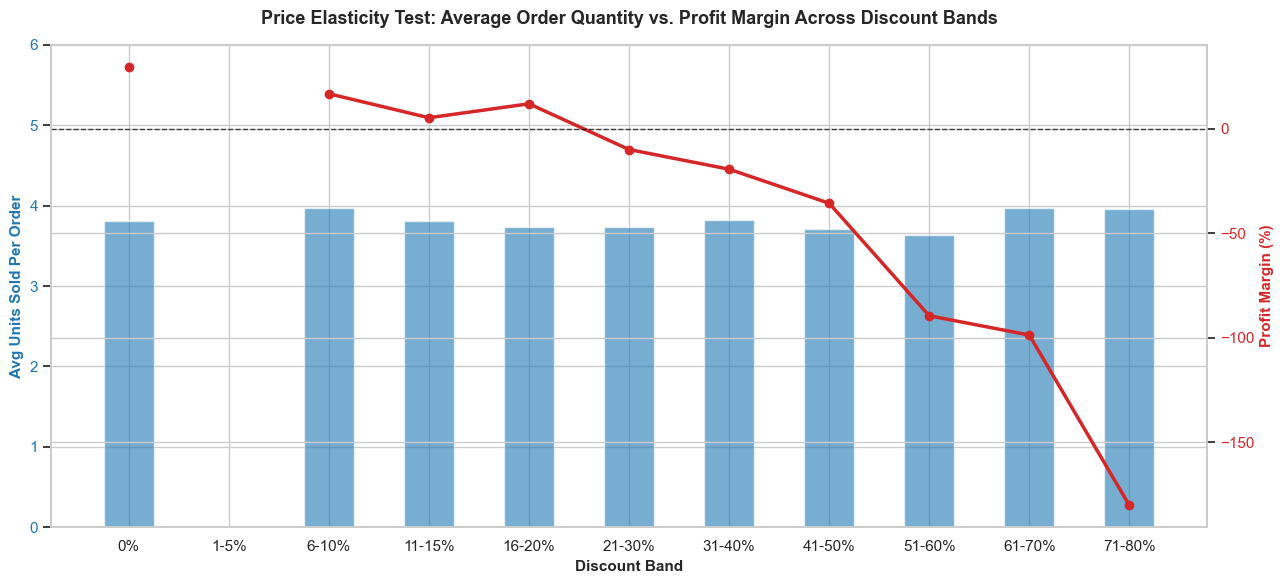

In [15]:
# 5. Visualisation: Dual-Axis Quantity vs Profit Margin across Bands
fig, ax1 = plt.subplots(figsize=(13, 6))

color = 'tab:blue'
ax1.set_xlabel('Discount Band', fontweight='bold', fontsize=11)
ax1.set_ylabel('Avg Units Sold Per Order', color=color, fontweight='bold', fontsize=11)
bars = ax1.bar(
    band_summary['Discount_Band'],
    band_summary['Avg_Units_Per_Order'],
    color=color,
    alpha=0.6,
    width=0.5,
    label='Avg Units / Order',
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 6)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Profit Margin (%)', color=color, fontweight='bold', fontsize=11)
line = ax2.plot(
    band_summary['Discount_Band'],
    band_summary['Avg_Profit_Margin'],
    color=color,
    linewidth=2.5,
    marker='o',
    label='Profit Margin %',
)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(
    'Price Elasticity Test: Average Order Quantity vs. Profit Margin Across Discount Bands',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
fig.tight_layout()
plt.savefig('price_elasticity_simulation.png', dpi=300)
plt.show()


In [16]:
# 6. Print Table
print(
    band_summary[
        [
            'Discount_Band',
            'Order_Count',
            'Avg_Units_Per_Order',
            'Total_Sales',
            'Total_Profit',
            'Avg_Profit_Margin',
            'Elasticity_Ed',
        ]
    ].to_string(index=False)
)


Discount_Band  Order_Count  Avg_Units_Per_Order  Total_Sales  Total_Profit  Avg_Profit_Margin  Elasticity_Ed
           0%         4798             3.807211 1087908.4700   320987.6032          29.505019       0.000000
         1-5%            0                  NaN       0.0000        0.0000                NaN            NaN
        6-10%           94             3.968085   54369.3510     9029.1770          16.607108      -0.528188
       11-15%           52             3.807692   27558.5215     1418.9915           5.149012      -0.000972
       16-20%         3657             3.735302  764594.3680    90337.3060          11.815063       0.104931
       21-30%          227             3.740088  103226.6550   -10369.2774         -10.045155       0.070522
       31-40%          233             3.824034  130911.2428   -25448.1881         -19.439269      -0.012625
       41-50%           77             3.714286   64403.5140   -22999.5392         -35.711622       0.054240
       51-60%      

# Q3b: Discount Tier A/B Significance Test (The 20% Cliff)

In [17]:
#1. Derive Profit Margin per order line
df['Profit_Margin'] = df['Profit'] / df['Sales']

In [18]:
# 2. Split into Group A (<= 20%) and Group B (> 20%)
group_a = df[df['Discount'] <= 0.20].copy()
group_b = df[df['Discount'] > 0.20].copy()

In [19]:
# 3. Descriptive Statistics
stats_summary = pd.DataFrame({
    'Metric': [
        'Sample Size (n)',
        'Total Sales ($)',
        'Total Profit ($)',
        'Mean Profit ($)',
        'Median Profit ($)',
        'Std Dev Profit ($)',
        'Mean Margin (%)',
        'Median Margin (%)',
    ],
    'Group A (Discount <= 20%)': [
        len(group_a),
        f"${group_a['Sales'].sum():,.2f}",
        f"${group_a['Profit'].sum():,.2f}",
        f"${group_a['Profit'].mean():.2f}",
        f"${group_a['Profit'].median():.2f}",
        f"${group_a['Profit'].std():.2f}",
        f"{group_a['Profit_Margin'].mean() * 100:.2f}%",
        f"{group_a['Profit_Margin'].median() * 100:.2f}%",
    ],
    'Group B (Discount > 20%)': [
        len(group_b),
        f"${group_b['Sales'].sum():,.2f}",
        f"${group_b['Profit'].sum():,.2f}",
        f"${group_b['Profit'].mean():.2f}",
        f"${group_b['Profit'].median():.2f}",
        f"${group_b['Profit'].std():.2f}",
        f"{group_b['Profit_Margin'].mean() * 100:.2f}%",
        f"{group_b['Profit_Margin'].median() * 100:.2f}%",
    ],
})

In [20]:
# 4. Inferential Statistical Testing (Dollar Profit)
# Welch's t-test (unequal variances)
t_stat_profit, p_val_profit = stats.ttest_ind(
    group_a['Profit'], group_b['Profit'], equal_var=False
)

# Mann-Whitney U test (non-parametric rank sum)
u_stat_profit, u_pval_profit = stats.mannwhitneyu(
    group_a['Profit'], group_b['Profit'], alternative='greater'
)

# Inferential Statistical Testing (Profit Margin %)
t_stat_margin, p_val_margin = stats.ttest_ind(
    group_a['Profit_Margin'], group_b['Profit_Margin'], equal_var=False
)
u_stat_margin, u_pval_margin = stats.mannwhitneyu(
    group_a['Profit_Margin'], group_b['Profit_Margin'], alternative='greater'
)


# Cohen's d Effect Size Function
def compute_cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(
        ((nx - 1) * x.std() ** 2 + (ny - 1) * y.std() ** 2) / dof
    )
    return (x.mean() - y.mean()) / pooled_std


d_profit = compute_cohens_d(group_a['Profit'], group_b['Profit'])
d_margin = compute_cohens_d(group_a['Profit_Margin'], group_b['Profit_Margin'])


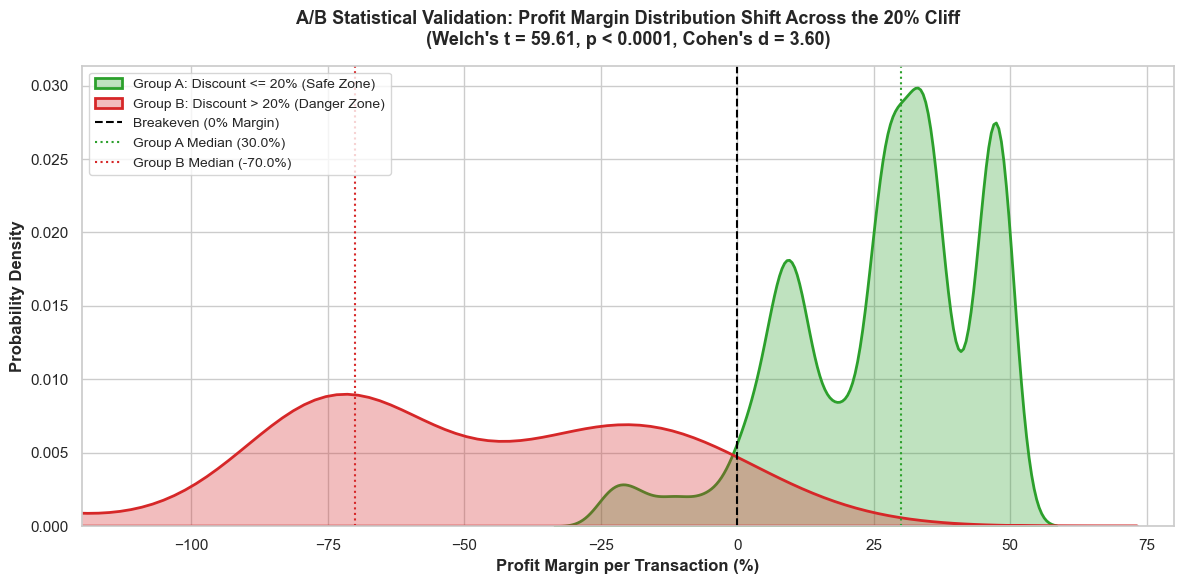

In [21]:
# 5. Visualization: Kernel Density Estimation (KDE) Comparison
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')

# Plot Profit Margin KDE distribution
sns.kdeplot(
    group_a['Profit_Margin'] * 100,
    label='Group A: Discount <= 20% (Safe Zone)',
    color='#2ca02c',
    fill=True,
    alpha=0.3,
    linewidth=2,
)
sns.kdeplot(
    group_b['Profit_Margin'] * 100,
    label='Group B: Discount > 20% (Danger Zone)',
    color='#d62728',
    fill=True,
    alpha=0.3,
    linewidth=2,
)

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Breakeven (0% Margin)',
)
plt.axvline(
    group_a['Profit_Margin'].median() * 100,
    color='#2ca02c',
    linestyle=':',
    linewidth=1.5,
    label=f"Group A Median ({group_a['Profit_Margin'].median()*100:.1f}%)",
)
plt.axvline(
    group_b['Profit_Margin'].median() * 100,
    color='#d62728',
    linestyle=':',
    linewidth=1.5,
    label=f"Group B Median ({group_b['Profit_Margin'].median()*100:.1f}%)",
)

plt.title(
    'A/B Statistical Validation: Profit Margin Distribution Shift Across the 20% Cliff\n'
    f"(Welch's t = {t_stat_margin:.2f}, p < 0.0001, Cohen's d = {d_margin:.2f})",
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Profit Margin per Transaction (%)', fontweight='bold')
plt.ylabel('Probability Density', fontweight='bold')
plt.xlim(-120, 80)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('ab_significance_test.png', dpi=300)
plt.show()

In [22]:
# 6. Print Report
print('=== DESCRIPTIVE COMPARISON ===')
print(stats_summary.to_string(index=False))
print('\n=== INFERENTIAL TEST RESULTS ===')
print(
    f"Dollar Profit Welch's t-test : t = {t_stat_profit:.2f}, p-value = {p_val_profit:.2e}"
)
print(
    f"Dollar Profit Mann-Whitney U : U = {u_stat_profit:.0f}, p-value = {u_pval_profit:.2e}"
)
print(f"Dollar Profit Cohen's d     : d = {d_profit:.3f} (Medium Effect)")
print('------------------------------------------------------------')
print(
    f"Profit Margin Welch's t-test : t = {t_stat_margin:.2f}, p-value = {p_val_margin:.2e}"
)
print(
    f"Profit Margin Mann-Whitney U : U = {u_stat_margin:.0f}, p-value = {u_pval_margin:.2e}"
)
print(
    f"Profit Margin Cohen's d     : d = {d_margin:.3f} (Extremely Large Effect)"
)

=== DESCRIPTIVE COMPARISON ===
            Metric Group A (Discount <= 20%) Group B (Discount > 20%)
   Sample Size (n)                      8601                     1393
   Total Sales ($)             $1,934,430.71              $362,770.15
  Total Profit ($)               $421,773.08             $-135,376.06
   Mean Profit ($)                    $49.04                  $-97.18
 Median Profit ($)                    $11.54                  $-18.25
Std Dev Profit ($)                   $208.38                  $327.54
   Mean Margin (%)                    26.69%                  -78.45%
 Median Margin (%)                    30.00%                  -70.00%

=== INFERENTIAL TEST RESULTS ===
Dollar Profit Welch's t-test : t = 16.14, p-value = 2.30e-54
Dollar Profit Mann-Whitney U : U = 11481792, p-value = 0.00e+00
Dollar Profit Cohen's d     : d = 0.639 (Medium Effect)
------------------------------------------------------------
Profit Margin Welch's t-test : t = 59.61, p-value = 0.00e+00
Pr

# Q4: Discount Cap Scenario Modeling (Counterfactual Simulation)

In [23]:
# 1. Derive base financial metrics
df['Cost'] = df['Sales'] - df['Profit']
df['Base_Price'] = df['Sales'] / (1 - df['Discount'])

In [24]:
# 2. Define Simulation Function
def simulate_cap(df, cap_rate=0.20, volume_loss=0.0):
    sim = df.copy()

    # Identify orders exceeding the cap
    over_cap_mask = sim['Discount'] > cap_rate

    # If volume loss occurs, randomly drop or discount volume factor
    # For deterministic modeling: scale sales and costs of over-cap items
    retention_rate = 1.0 - volume_loss

    # For orders <= cap: unchanged
    # For orders > cap: recalculate at capped rate
    sim['Sim_Sales'] = sim['Sales']
    sim['Sim_Profit'] = sim['Profit']

    # Apply cap to sales
    sim.loc[over_cap_mask, 'Sim_Sales'] = (
        sim.loc[over_cap_mask, 'Base_Price'] * (1 - cap_rate) * retention_rate
    )

    # Cost scales with retained volume
    sim_cost = sim['Cost'].copy()
    sim_cost.loc[over_cap_mask] = sim_cost.loc[over_cap_mask] * retention_rate

    sim['Sim_Profit'] = sim['Sim_Sales'] - sim_cost

    return {
        'Cap_Rate': f'{int(cap_rate*100)}%',
        'Volume_Drop': f'{int(volume_loss*100)}%',
        'Total_Sales': sim['Sim_Sales'].sum(),
        'Total_Profit': sim['Sim_Profit'].sum(),
        'Profit_Margin': (sim['Sim_Profit'].sum() / sim['Sim_Sales'].sum())
        * 100,
        'Profit_Lift': sim['Sim_Profit'].sum() - df['Profit'].sum(),
    }


In [25]:
# 3. Run Scenarios
results = []
# Baseline (Actuals)
results.append({
    'Cap_Rate': 'Actual (No Cap)',
    'Volume_Drop': '0%',
    'Total_Sales': df['Sales'].sum(),
    'Total_Profit': df['Profit'].sum(),
    'Profit_Margin': (df['Profit'].sum() / df['Sales'].sum()) * 100,
    'Profit_Lift': 0.0,
})

# Scenarios for 20% Cap
results.append(simulate_cap(df, cap_rate=0.20, volume_loss=0.00))
results.append(simulate_cap(df, cap_rate=0.20, volume_loss=0.10))
results.append(simulate_cap(df, cap_rate=0.20, volume_loss=0.20))

# Scenarios for 15% Cap
results.append(simulate_cap(df, cap_rate=0.15, volume_loss=0.00))
results.append(simulate_cap(df, cap_rate=0.15, volume_loss=0.10))

sim_results = pd.DataFrame(results)

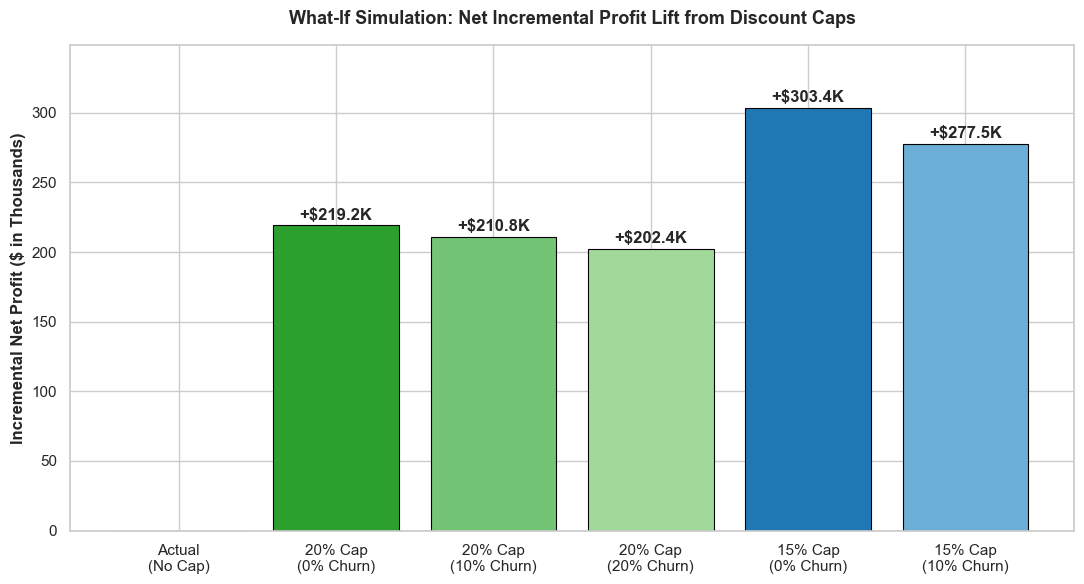

In [26]:
# . Visualization: Profit Lift by Scenario
plt.figure(figsize=(11, 6))
scenarios = [
    'Actual\n(No Cap)',
    '20% Cap\n(0% Churn)',
    '20% Cap\n(10% Churn)',
    '20% Cap\n(20% Churn)',
    '15% Cap\n(0% Churn)',
    '15% Cap\n(10% Churn)',
]
profit_lifts = sim_results['Profit_Lift'] / 1000

colors = ['grey', '#2ca02c', '#74c476', '#a1d99b', '#1f77b4', '#6baed6']
bars = plt.bar(
    scenarios, profit_lifts, color=colors, edgecolor='black', linewidth=0.8
)

for bar in bars:
    yval = bar.get_height()
    if yval != 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 2,
            f'+${yval:,.1f}K',
            ha='center',
            va='bottom',
            fontweight='bold',
        )

plt.title(
    'What-If Simulation: Net Incremental Profit Lift from Discount Caps',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.ylabel('Incremental Net Profit ($ in Thousands)', fontweight='bold')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(0, max(profit_lifts) * 1.15)
plt.tight_layout()
plt.savefig('discount_cap_simulation.png', dpi=300)
plt.show()

In [27]:
# 6. Display Summary Table
print(sim_results.round(2).to_string(index=False))

       Cap_Rate Volume_Drop  Total_Sales  Total_Profit  Profit_Margin  Profit_Lift
Actual (No Cap)          0%   2297200.86     286397.02          12.47         0.00
            20%          0%   2516391.85     505588.02          20.09    219190.99
            20%         10%   2458195.74     497206.52          20.23    210809.50
            20%         20%   2399999.63     488825.03          20.37    202428.01
            15%          0%   2600551.57     589747.74          22.68    303350.71
            15%         10%   2457480.05     563916.54          22.95    277519.52


# Q4 b: Multi-Scenario Discount Cap Simulation, expanded to test the full policy spectrum (15%, 20%, 25%, and 30% caps) along with volume elasticity stress tests.

In [28]:
# 1. Derive base financial metrics
df['Cost'] = df['Sales'] - df['Profit']
df['Base_Price'] = df['Sales'] / (1 - df['Discount'])


In [29]:
# 2. Multi-Scenario Simulation Function
def simulate_cap(df, cap_rate, volume_loss=0.0):
  sim = df.copy()
  over_cap_mask = sim['Discount'] > cap_rate
  retention_rate = 1.0 - volume_loss

  sim['Sim_Sales'] = sim['Sales']
  sim.loc[over_cap_mask, 'Sim_Sales'] = (
      sim.loc[over_cap_mask, 'Base_Price'] * (1 - cap_rate) * retention_rate
  )

  sim_cost = sim['Cost'].copy()
  sim_cost.loc[over_cap_mask] = sim_cost.loc[over_cap_mask] * retention_rate
  sim['Sim_Profit'] = sim['Sim_Sales'] - sim_cost

  return {
      'Cap_Rate': f'{int(cap_rate*100)}%',
      'Volume_Drop': f'{int(volume_loss*100)}%',
      'Total_Sales': sim['Sim_Sales'].sum(),
      'Total_Profit': sim['Sim_Profit'].sum(),
      'Profit_Margin': (sim['Sim_Profit'].sum() / sim['Sim_Sales'].sum()) * 100,
      'Profit_Lift': sim['Sim_Profit'].sum() - df['Profit'].sum(),
      'Pct_Lift': (
          (sim['Sim_Profit'].sum() - df['Profit'].sum()) / df['Profit'].sum()
      )
      * 100,
  }

In [30]:
# 3. Run Across 15%, 20%, 25%, and 30% Caps
caps = [0.30, 0.25, 0.20, 0.15]
churn_rates = [0.00, 0.10, 0.20]

results = []
# Add Actual Baseline
results.append({
    'Cap_Rate': 'Actual (No Cap)',
    'Volume_Drop': '0%',
    'Total_Sales': df['Sales'].sum(),
    'Total_Profit': df['Profit'].sum(),
    'Profit_Margin': (df['Profit'].sum() / df['Sales'].sum()) * 100,
    'Profit_Lift': 0.0,
    'Pct_Lift': 0.0,
})

for c in caps:
  for churn in churn_rates:
    results.append(simulate_cap(df, cap_rate=c, volume_loss=churn))

sim_results = pd.DataFrame(results)


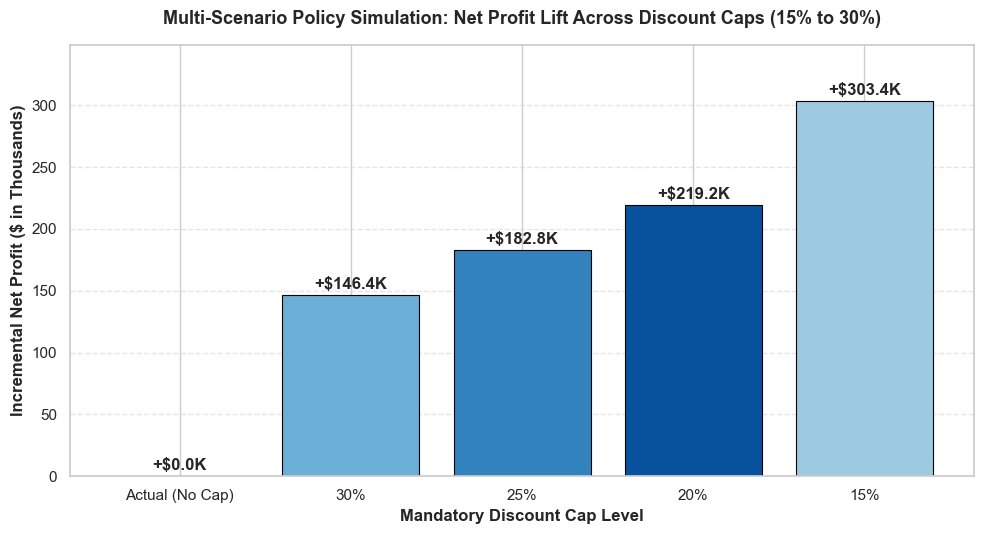

In [31]:
# 4. Visualization: Comparative Profit Lift Across All 4 Caps (0% Churn baseline)
plot_data = sim_results[
    (sim_results['Volume_Drop'] == '0%') & (sim_results['Cap_Rate'] != 'Actual')
].copy()

plt.figure(figsize=(10, 5.5))
bars = plt.bar(
    plot_data['Cap_Rate'],
    plot_data['Profit_Lift'] / 1000,
    color=['#9ecae1', '#6baed6', '#3182bd', '#08519c'],
    edgecolor='black',
    linewidth=0.8,
)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 2.5,
      f'+${yval:,.1f}K',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.title(
    'Multi-Scenario Policy Simulation: Net Profit Lift Across Discount Caps'
    ' (15% to 30%)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Mandatory Discount Cap Level', fontweight='bold')
plt.ylabel('Incremental Net Profit ($ in Thousands)', fontweight='bold')
plt.ylim(0, max(plot_data['Profit_Lift'] / 1000) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('multi_scenario_discount_caps.png', dpi=300)
plt.show()


In [32]:
# 6. Print Formatted Table
print(sim_results.round(2).to_string(index=False))

       Cap_Rate Volume_Drop  Total_Sales  Total_Profit  Profit_Margin  Profit_Lift  Pct_Lift
Actual (No Cap)          0%   2297200.86     286397.02          12.47         0.00      0.00
            30%          0%   2443646.71     432842.87          17.71    146445.85     51.13
            30%         10%   2403047.78     430698.97          17.92    144301.94     50.39
            30%         20%   2362448.84     428555.06          18.14    142158.04     49.64
            25%          0%   2480019.28     469215.44          18.92    182818.42     63.83
            25%         10%   2425460.43     464471.21          19.15    178074.19     62.18
            25%         20%   2370901.57     459726.97          19.39    173329.95     60.52
            20%          0%   2516391.85     505588.02          20.09    219190.99     76.53
            20%         10%   2458195.74     497206.52          20.23    210809.50     73.61
            20%         20%   2399999.63     488825.03          20.37 

#  Q5: RFM Customer Segmentation & Profitability Clustering

In [33]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [34]:
# 1. Reference date: day after final order date
snapshot_date = df['Order Date'].max() + dt.timedelta(days=1)

In [35]:
# 2. Aggregate RFM-P Metrics per Customer
rfm = (
    df.groupby('Customer ID')
    .agg(
        Customer_Name=('Customer Name', 'first'),
        Segment=('Segment', 'first'),
        Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
        Frequency=('Order ID', 'nunique'),
        Monetary=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Avg_Discount=('Discount', 'mean'),
    )
    .reset_index()
)

rfm['Profit_Margin'] = (rfm['Profit'] / rfm['Monetary']) * 100


In [36]:
# 3. Calculate RFM Quartile Scores (1 to 4)
# Recency: lower is better (inverted)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
# Frequency: use rank-based binning to handle ties
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine into overall RFM Segment
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

In [37]:
# 4. Map to Behavioral Customer Segments
def assign_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions / Core VIPs'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent / New'
    elif r <= 2 and f >= 3:
        return 'At Risk / Slipping'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'High-Spend Dormant'
    else:
        return 'Hibernating / Low Engagement'


rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)


In [38]:
# 5. Summarize Segment Economics
segment_analysis = (
    rfm.groupby('Segment')
    .agg(
        Customer_Count=('Customer ID', 'count'),
        Total_Sales=('Monetary', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Discount=('Avg_Discount', lambda x: x.mean() * 100),
        Unprofitable_Accounts=('Profit', lambda x: (x < 0).sum()),
    )
    .reset_index()
)

segment_analysis['Profit_Margin'] = (
    segment_analysis['Total_Profit'] / segment_analysis['Total_Sales']
) * 100
segment_analysis['Unprofitable_Pct'] = (
    segment_analysis['Unprofitable_Accounts']
    / segment_analysis['Customer_Count']
) * 100

segment_analysis = segment_analysis.sort_values(
    by='Total_Profit', ascending=False
)


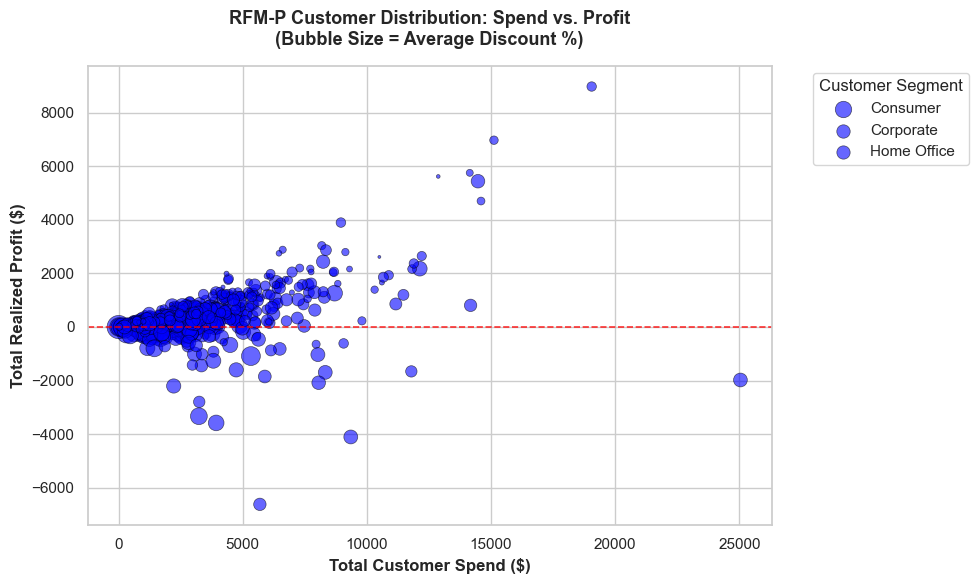

In [39]:
# 6. Visualization: Sales vs Profit by Segment with Bubble Size = Discount
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

colors = {
    'Champions / Core VIPs': '#2ca02c',
    'Loyal Customers': '#1f77b4',
    'At Risk / Slipping': '#ff7f0e',
    'Recent / New': '#17becf',
    'High-Spend Dormant': '#d62728',
    'Hibernating / Low Engagement': '#7f7f7f',
}

for seg, data in rfm.groupby('Segment'):
    plt.scatter(
        data['Monetary'],
        data['Profit'],
        label=seg,
        alpha=0.6,
        s=data['Avg_Discount'] * 400,
        c=colors.get(seg, 'blue'),
        edgecolors='black',
        linewidth=0.5,
    )

plt.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
plt.title(
    'RFM-P Customer Distribution: Spend vs. Profit\n(Bubble Size = Average Discount %)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Total Customer Spend ($)', fontweight='bold')
plt.ylabel('Total Realized Profit ($)', fontweight='bold')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('rfm_profitability_scatter.png', dpi=300)
plt.show()


In [40]:
# 7. Print Segment Financial Summary
print(
    segment_analysis[
        [
            'Segment',
            'Customer_Count',
            'Total_Sales',
            'Total_Profit',
            'Profit_Margin',
            'Avg_Discount',
            'Unprofitable_Accounts',
            'Unprofitable_Pct',
        ]
    ].to_string(index=False)
)


    Segment  Customer_Count  Total_Sales  Total_Profit  Profit_Margin  Avg_Discount  Unprofitable_Accounts  Unprofitable_Pct
   Consumer             409 1161401.3450   134119.2092      11.548050     16.043079                     84         20.537897
  Corporate             236  706146.3668    91979.1340      13.025506     16.035772                     47         19.915254
Home Office             148  429653.1485    60298.6785      14.034269     14.474574                     24         16.216216


# Q6: Pareto Analysis (80/20 Rule) & Cumulative Margin Concentration

In [41]:
# 2. Aggregate Profit and Sales by Customer
cust_profit = (
    df.groupby('Customer ID')
    .agg(
        Customer_Name=('Customer Name', 'first'),
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Order_Count=('Order ID', 'nunique'),
        Avg_Discount=('Discount', 'mean'),
    )
    .reset_index()
)

In [42]:
# 3. Sort descending by Profit for the Pareto / Whale Curve
cust_profit = cust_profit.sort_values(by='Total_Profit', ascending=False).reset_index(drop=True)

In [43]:
# 4. Compute Cumulative Percentages
total_profit = cust_profit['Total_Profit'].sum()
total_sales = cust_profit['Total_Sales'].sum()
total_customers = len(cust_profit)

cust_profit['Customer_Rank'] = cust_profit.index + 1
cust_profit['Cum_Customer_Pct'] = (cust_profit['Customer_Rank'] / total_customers) * 100
cust_profit['Cum_Profit'] = cust_profit['Total_Profit'].cumsum()
cust_profit['Cum_Profit_Pct'] = (cust_profit['Cum_Profit'] / total_profit) * 100

cust_profit['Cum_Sales'] = cust_profit['Total_Sales'].cumsum()
cust_profit['Cum_Sales_Pct'] = (cust_profit['Cum_Sales'] / total_sales) * 100


In [44]:
# 5. Identify Critical Thresholds
peak_profit = cust_profit['Cum_Profit'].max()
peak_idx = cust_profit['Cum_Profit'].idxmax()
peak_cust_pct = cust_profit.loc[peak_idx, 'Cum_Customer_Pct']
peak_profit_pct = cust_profit.loc[peak_idx, 'Cum_Profit_Pct']

# Top 20% Customer Metrics
top_20_idx = int(total_customers * 0.20)
top_20_sales_pct = cust_profit.loc[top_20_idx, 'Cum_Sales_Pct']
top_20_profit_pct = cust_profit.loc[top_20_idx, 'Cum_Profit_Pct']


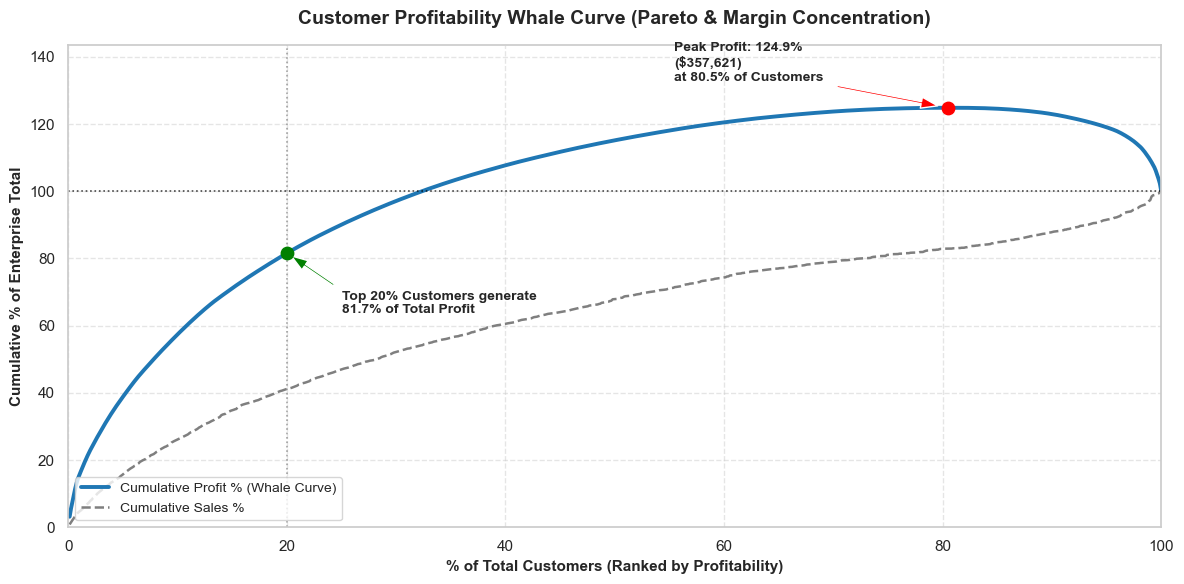

In [45]:
# 6. Visualization: The Customer Profit Whale Curve
plt.figure(figsize=(12, 6))
plt.plot(
    cust_profit['Cum_Customer_Pct'],
    cust_profit['Cum_Profit_Pct'],
    color='#1f77b4',
    linewidth=2.8,
    label='Cumulative Profit % (Whale Curve)'
)
plt.plot(
    cust_profit['Cum_Customer_Pct'],
    cust_profit['Cum_Sales_Pct'],
    color='#7f7f7f',
    linestyle='--',
    linewidth=1.8,
    label='Cumulative Sales %'
)

# Reference 100% and 80% lines
plt.axhline(100, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
plt.axvline(20, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)

# Highlight Peak Profit Point
plt.scatter([peak_cust_pct], [peak_profit_pct], color='red', s=80, zorder=5)
plt.annotate(
    f'Peak Profit: {peak_profit_pct:.1f}%\n(${peak_profit:,.0f})\nat {peak_cust_pct:.1f}% of Customers',
    xy=(peak_cust_pct, peak_profit_pct),
    xytext=(peak_cust_pct - 25, peak_profit_pct + 8),
    arrowprops=dict(facecolor='red', shrink=0.08, width=1.5, headwidth=8),
    fontweight='bold',
    fontsize=10
)

# Highlight Top 20% Pareto Marker
plt.scatter([20], [top_20_profit_pct], color='green', s=80, zorder=5)
plt.annotate(
    f'Top 20% Customers generate\n{top_20_profit_pct:.1f}% of Total Profit',
    xy=(20, top_20_profit_pct),
    xytext=(25, top_20_profit_pct - 18),
    arrowprops=dict(facecolor='green', shrink=0.08, width=1.5, headwidth=8),
    fontweight='bold',
    fontsize=10
)

plt.title('Customer Profitability Whale Curve (Pareto & Margin Concentration)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% of Total Customers (Ranked by Profitability)', fontweight='bold', fontsize=11)
plt.ylabel('Cumulative % of Enterprise Total', fontweight='bold', fontsize=11)
plt.xlim(0, 100)
plt.ylim(0, max(peak_profit_pct * 1.15, 140))
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pareto_whale_curve.png', dpi=300)
plt.show()

In [46]:
# 7. Print Decile Breakdown Table
cust_profit['Decile'] = pd.qcut(cust_profit.index, 10, labels=[f'D{i}' for i in range(1, 11)])
decile_summary = cust_profit.groupby('Decile').agg(
    Customers=('Customer ID', 'count'),
    Decile_Sales=('Total_Sales', 'sum'),
    Decile_Profit=('Total_Profit', 'sum'),
    Avg_Discount=('Avg_Discount', lambda x: x.mean() * 100)
).reset_index()
decile_summary['Profit_Margin'] = (decile_summary['Decile_Profit'] / decile_summary['Decile_Sales']) * 100
decile_summary['Pct_Total_Profit'] = (decile_summary['Decile_Profit'] / total_profit) * 100

print(decile_summary.to_string(index=False))

Decile  Customers  Decile_Sales  Decile_Profit  Avg_Discount  Profit_Margin  Pct_Total_Profit
    D1         80   603295.2609    165235.4062     10.891161      27.388812         57.694527
    D2         79   342869.1513     68650.0657     12.275955      20.022235         23.970244
    D3         79   253223.8907     44306.4885     11.931100      17.496962         15.470304
    D4         79   191379.7792     30305.5485     11.927752      15.835293         10.581656
    D5         80   169884.5822     21468.8601     15.666793      12.637321          7.496188
    D6         79   147724.2473     15242.1468     15.073284      10.317972          5.322034
    D7         79   105962.4380      9188.4220     15.356131       8.671395          3.208281
    D8         79    89132.3460      3223.0733     16.408437       3.616053          1.125386
    D9         79   112869.4166     -5281.0938     23.464067      -4.678941         -1.843977
   D10         80   280859.7481    -65941.8956     24.439509

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18076\483886444.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_summary = cust_profit.groupby('Decile').agg(


# Q7 : Safe Clearance Discount Table

In [47]:
# 1. Derive List Price and Cost for each transaction
df['Cost'] = df['Sales'] - df['Profit']
df['List_Price'] = df['Sales'] / (1 - df['Discount'])


In [48]:
# 2. Aggregate at Sub-Category Level to establish baseline cost structure
clearance = (
    df.groupby('Sub-Category')
    .agg(
        Category=('Category', 'first'),
        Total_List_Price=('List_Price', 'sum'),
        Total_Cost=('Cost', 'sum'),
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Historical_Avg_Discount=('Discount', 'mean'),
    )
    .reset_index()
)

In [49]:
# 3. Calculate Empirical Baseline Margin & Breakeven Discount
clearance['Cost_Ratio'] = (
    clearance['Total_Cost'] / clearance['Total_List_Price']
)
clearance['Full_Price_Margin_Pct'] = (1 - clearance['Cost_Ratio']) * 100

# Breakeven Discount Ceiling: Profit = $0
clearance['Breakeven_Discount_Ceiling'] = clearance['Full_Price_Margin_Pct']

# Safe Clearance Cap: Protects a 5% Profit Margin
clearance['Safe_Clearance_Cap_5Pct'] = (
    1 - (clearance['Cost_Ratio'] / 0.95)
) * 100
clearance['Safe_Clearance_Cap_5Pct'] = clearance[
    'Safe_Clearance_Cap_5Pct'
].clip(lower=0.0)

# Sort by Category and Margin
clearance = clearance.sort_values(
    by=['Category', 'Breakeven_Discount_Ceiling'], ascending=[True, False]
)

In [50]:
# 4. Format Display Table
output_table = clearance[
    [
        'Sub-Category',
        'Category',
        'Full_Price_Margin_Pct',
        'Breakeven_Discount_Ceiling',
        'Safe_Clearance_Cap_5Pct',
        'Historical_Avg_Discount',
    ]
].copy()

output_table['Historical_Avg_Discount'] = (
    output_table['Historical_Avg_Discount'] * 100
).round(1).astype(str) + '%'
output_table['Full_Price_Margin_Pct'] = (
    output_table['Full_Price_Margin_Pct'].round(1).astype(str) + '%'
)
output_table['Breakeven_Discount_Ceiling'] = (
    output_table['Breakeven_Discount_Ceiling'].round(1).astype(str) + '%'
)
output_table['Safe_Clearance_Cap_5Pct'] = (
    output_table['Safe_Clearance_Cap_5Pct'].round(1).astype(str) + '%'
)

print(output_table.to_string(index=False))

Sub-Category        Category Full_Price_Margin_Pct Breakeven_Discount_Ceiling Safe_Clearance_Cap_5Pct Historical_Avg_Discount
 Furnishings       Furniture                 26.9%                      26.9%                   23.0%                   13.8%
      Chairs       Furniture                 23.4%                      23.4%                   19.3%                   17.0%
   Bookcases       Furniture                 20.1%                      20.1%                   15.9%                   21.1%
      Tables       Furniture                 19.1%                      19.1%                   14.8%                   26.1%
      Labels Office Supplies                 47.8%                      47.8%                   45.1%                    6.9%
     Binders Office Supplies                 47.8%                      47.8%                   45.0%                   37.2%
       Paper Office Supplies                 47.6%                      47.6%                   44.9%                 

# Q8: : Stock Redistribution Framework (Inter-Regional Arbitrage & Freight Decision Rule)

In [53]:
# Benchmark parameters for Tables — derived from actual data, not assumed
tables_df = df[df['Sub-Category'] == 'Tables']
list_price = (tables_df['Sales'] / (1 - tables_df['Discount'])).sum() / tables_df['Quantity'].sum()
unit_cost = (tables_df['Sales'] - tables_df['Profit']).sum() / tables_df['Quantity'].sum()
print(f"Derived list price: ${list_price:.2f}, Derived unit cost: ${unit_cost:.2f}")

Derived list price: $223.76, Derived unit cost: $181.06


In [55]:
scenarios = [
    {
        'Strategy': 'Local Distress Clearance (Central/East)',
        'Discount': 0.40,
        'Freight_Transfer': 0.00,
    },
    {
        'Strategy': 'Deep Local Clearance (Texas/Ohio)',
        'Discount': 0.50,
        'Freight_Transfer': 0.00,
    },
    {
        'Strategy': 'Transfer to West (Standard Freight)',
        'Discount': 0.15,
        'Freight_Transfer': 45.00,
    },
    {
        'Strategy': 'Transfer to West (Consolidated Bulk LTL)',
        'Discount': 0.12,
        'Freight_Transfer': 25.00,
    },
    {
        'Strategy': 'Transfer to West (Expedited Transit)',
        'Discount': 0.15,
        'Freight_Transfer': 85.00,
    },
]

results = []
for s in scenarios:
    realized_sales = list_price * (1 - s['Discount'])
    net_profit = realized_sales - unit_cost - s['Freight_Transfer']
    profit_margin = (net_profit / realized_sales) * 100
    results.append({
        'Strategy': s['Strategy'],
        'Realized Price ($)': realized_sales,
        'Discount (%)': f"{int(s['Discount']*100)}%",
        'Transfer Freight ($)': s['Freight_Transfer'],
        'Net Profit ($/unit)': net_profit,
        'Profit Margin (%)': f'{profit_margin:.1f}%',
        'Net Advantage vs 40% Clearance': net_profit
        - (list_price * 0.60 - unit_cost),
    })

sim_df = pd.DataFrame(results)
print(sim_df.to_string(index=False))

                                Strategy  Realized Price ($) Discount (%)  Transfer Freight ($)  Net Profit ($/unit) Profit Margin (%)  Net Advantage vs 40% Clearance
 Local Distress Clearance (Central/East)          134.256774          40%                   0.0           -46.799643            -34.9%                        0.000000
       Deep Local Clearance (Texas/Ohio)          111.880645          50%                   0.0           -69.175772            -61.8%                      -22.376129
     Transfer to West (Standard Freight)          190.197096          15%                  45.0           -35.859321            -18.9%                       10.940322
Transfer to West (Consolidated Bulk LTL)          196.909935          12%                  25.0            -9.146482             -4.6%                       37.653161
    Transfer to West (Expedited Transit)          190.197096          15%                  85.0           -75.859321            -39.9%                      -29.05967